In [1]:
import sympy as sp


In [15]:
from isb_lib import ISB
import matplotlib.pyplot as plt
import numpy as np

$$y[n]=\alpha.x[n]+(1-\alpha).y[n-1]$$

Donde:
- $y[n]$: Muestra actual de la señal de salida filtrada.
- $y[n-1]$: Muestra previa de la salida.
- $x[n]$: Muestra actual de la señal de entrada.
- $\alpha$: Factor de ponderación o suavizado ($0 < \alpha < 1$).

$f_{c}=\frac{1}{2\pi.R.C}$

$\alpha=\frac{T_{s}}{RC+T_{s}}$

$\alpha = \frac{2\pi.fc.T_{s}}{1+2\pi.fc.T_{s}}$

- A menor valor de $\alpha$, mayor atenuación de altas frecuencias (filtro más agresivo, mayor retardo de fase).
- Cuando $\alpha \to 1$, la señal pasa prácticamente sin filtrar.

In [2]:
z = sp.symbols("z")

In [19]:
fs = 1e3
fc = 100
alpha = (2*np.pi*fc*1/fs)/(1+2*np.pi*fc*1/fs)

alpha

0.38586954509503757

In [20]:
#alpha=0.9

num = alpha*z
den = z - (1-alpha)

H_z = num/den

H_z

0.385869545095038*z/(z - 0.614130454904962)

## GRáficas

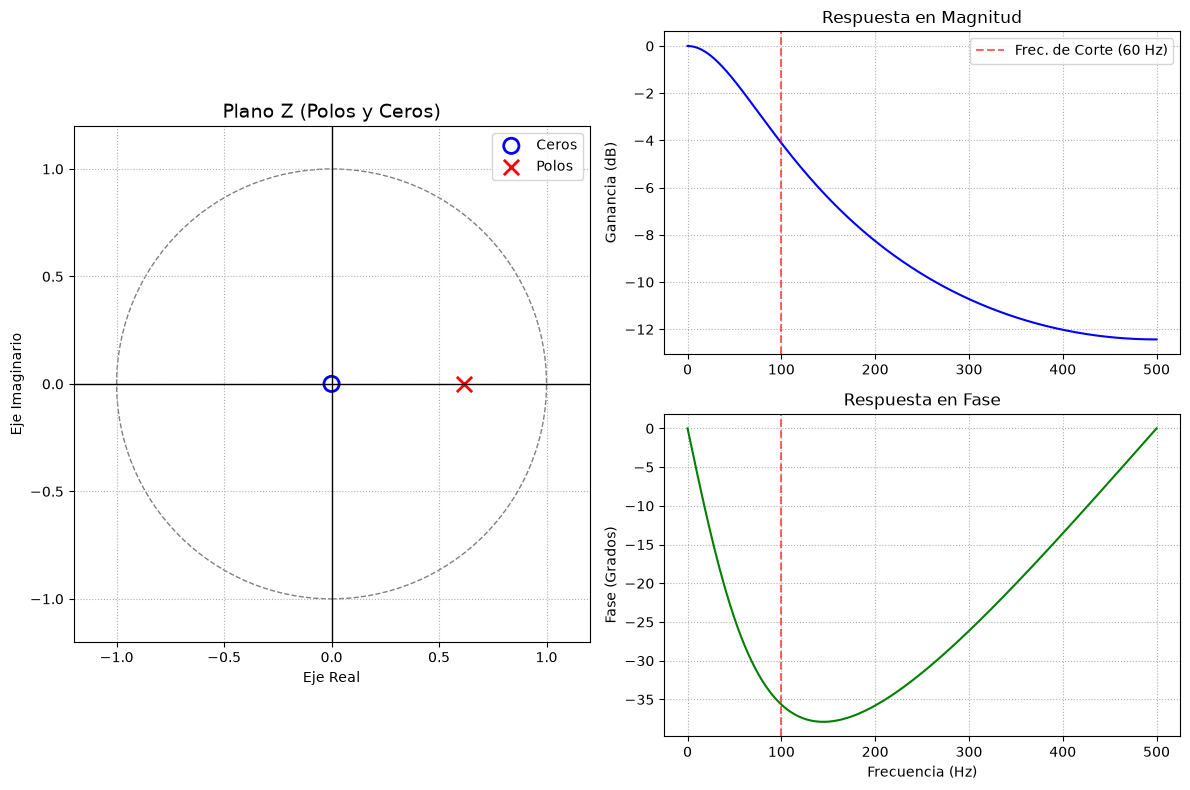

In [21]:
# ==========================================
# 2. EXTRACCIÓN DE POLOS Y CEROS (SYMPY)
# ==========================================
# Resolvemos H(z) = 0 (ceros) y el denominador = 0 (polos)
ceros_sym = sp.solve(num, z)
polos_sym = sp.solve(den, z)

# Convertimos los resultados simbólicos a tipos complejos nativos de Python
ceros = [complex(c.evalf()) for c in ceros_sym]
polos = [complex(p.evalf()) for p in polos_sym]

w = sp.Symbol('omega', real=True)
Fs = fs
f0=fc
# ==========================================
# 3. RESPUESTA EN FRECUENCIA (BODE)
# ==========================================
# Sustituimos z = e^(jw) en H(z) para evaluar la respuesta frecuencial
H_w = H_z.subs(z, sp.exp(sp.I * w))

# lambdify convierte la expresión de SymPy en una función rápida de NumPy
H_func = sp.lambdify(w, H_w, modules="numpy")

# Generamos un vector de frecuencias digitales (de 0 a pi)
w_vals = np.linspace(0, np.pi, 1000)
freq_hz = w_vals * (Fs / (2 * np.pi)) # Conversión a Hz reales

# Evaluamos la función y calculamos magnitud (dB) y fase (grados)
H_vals = H_func(w_vals)
magnitud_db = 20 * np.log10(np.abs(H_vals))
fase_deg = np.angle(H_vals, deg=True)

# ==========================================
# 4. VISUALIZACIÓN MULTIPANEL
# ==========================================
fig = plt.figure(figsize=(12, 8))

# --- Gráfico 1: Plano Complejo (Polos y Ceros) ---
ax1 = plt.subplot(1, 2, 1)
circulo = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
ax1.add_patch(circulo)
ax1.axhline(0, color='black', lw=1)
ax1.axvline(0, color='black', lw=1)
ax1.scatter([np.real(c) for c in ceros], [np.imag(c) for c in ceros], 
            s=120, facecolors='none', edgecolors='blue', marker='o', lw=2, label='Ceros')
ax1.scatter([np.real(p) for p in polos], [np.imag(p) for p in polos], 
            s=120, color='red', marker='x', lw=2, label='Polos')
ax1.set_xlim([-1.2, 1.2])
ax1.set_ylim([-1.2, 1.2])
ax1.set_aspect('equal')
ax1.set_title("Plano Z (Polos y Ceros)", fontsize=14)
ax1.set_xlabel("Eje Real")
ax1.set_ylabel("Eje Imaginario")
ax1.grid(True, linestyle=':')
ax1.legend()

# --- Gráfico 2: Magnitud (Bode Superior) ---
ax2 = plt.subplot(2, 2, 2)
ax2.plot(freq_hz, magnitud_db, 'b')
ax2.axvline(f0, color='red', linestyle='--', alpha=0.6, label='Frec. de Corte (60 Hz)')
ax2.set_title("Respuesta en Magnitud", fontsize=12)
ax2.set_ylabel("Ganancia (dB)")
ax2.grid(True, linestyle=':')
ax2.legend()

# --- Gráfico 3: Fase (Bode Inferior) ---
ax3 = plt.subplot(2, 2, 4, sharex=ax2)
ax3.plot(freq_hz, fase_deg, 'green')
ax3.axvline(f0, color='red', linestyle='--', alpha=0.6)
ax3.set_title("Respuesta en Fase", fontsize=12)
ax3.set_xlabel("Frecuencia (Hz)")
ax3.set_ylabel("Fase (Grados)")
ax3.grid(True, linestyle=':')

plt.tight_layout()
plt.show()